## Gradient Analysis — Mixing Method Comparison

This notebook analyses per-round gradient behaviour and convergence metrics for three decentralised gossip-based mixing methods: **MATCHA**, **Max Degree**, and **Metropolis-Hastings**, compared across two gossip configurations:

| Config | Directory | Description |
|--------|-----------|-------------|
| **5-Gossip** | `ng_rounds` | Multiple gossip steps per round |
| **1-Gossip** | `1g_rounds` | Single gossip step per round |

**Visual convention throughout all plots:**
- **Solid lines** — 5-Gossip (`ng_rounds`)
- **Dashed lines** — 1-Gossip (`1g_rounds`)
- **Colour** — identifies the mixing method

### Cell 1 — Setup & Weighted Gradient Norm (All Methods)
Loads configuration, defines helpers, and plots the **weighted gradient sum norm** $\|\vec{G}^{(t)}\|_2$ per round for all method × config combinations:
$$\|\vec{G}^{(t)}\|_2 = \left\|\sum_i \frac{n_i}{\sum_j n_j} \cdot g_i^{(t)}\right\|_2$$


5-Gossip / MATCHA: OK
5-Gossip / Max Degree: OK
5-Gossip / Metropolis-Hastings: OK
1-Gossip / MATCHA: OK
1-Gossip / Max Degree: OK
1-Gossip / Metropolis-Hastings: OK


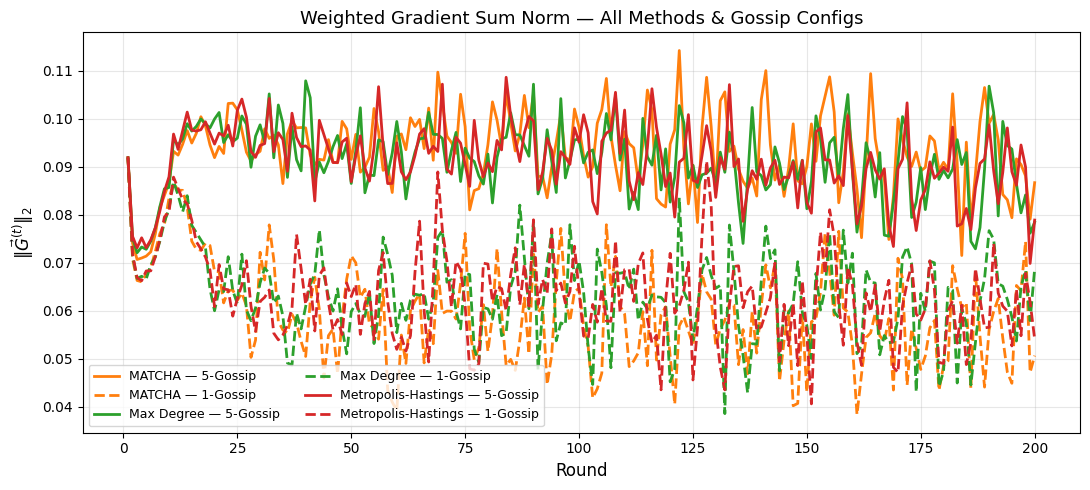

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Configuration ─────────────────────────────────────────────────────────────
LOGS_ROOT = Path('logs')

METHODS = {
    'MATCHA':               LOGS_ROOT / 'matcha_comparison',
    'Max Degree':           LOGS_ROOT / 'max_degree_comparison',
    'Metropolis-Hastings':  LOGS_ROOT / 'metropolis_hastings_comparison',
}

# Maps display label → subdirectory name
GOSSIP_CONFIGS = {
    '5-Gossip': 'ng_rounds',
    '1-Gossip': '1g_rounds',
}

colors     = ['#ff7f0e', '#2ca02c', '#d62728']          # one per method
markers    = []  # markers disabled
linestyles = {'5-Gossip': '-', '1-Gossip': '--'}        # solid vs dashed

FIG_DIR = Path('report/figures')
DPI     = 150

def get_exp_dir(method_base: Path, config_subdir: str) -> Path:
    return method_base / config_subdir

def compute_weighted_grad_norms(exp_dir: Path):
    """Load per-client gradient .npy files and return {round: ||G(t)||_2}."""
    grad_dir    = exp_dir / 'all_gradients'
    metrics_csv = exp_dir / 'p2p_metrics.csv'

    files = list(grad_dir.glob('client_*_round_*.npy'))
    if not files:
        raise FileNotFoundError(f'No gradient files in {grad_dir}')

    rounds_set, clients_set = set(), set()
    for f in files:
        parts = f.stem.split('_')
        clients_set.add(int(parts[1]))
        rounds_set.add(int(parts[3]))
    rounds     = sorted(rounds_set)
    client_ids = sorted(clients_set)

    if metrics_csv.exists():
        df = pd.read_csv(metrics_csv)
        if 'num_samples' in df.columns and df['num_samples'].notna().all():
            r0 = df[df['round'] == rounds[0]].set_index('client_id')
            num_samples = {cid: int(r0.loc[cid, 'num_samples']) for cid in client_ids}
        else:
            num_samples = {cid: 1 for cid in client_ids}
    else:
        num_samples = {cid: 1 for cid in client_ids}

    total   = sum(num_samples.values())
    weights = {cid: num_samples[cid] / total for cid in client_ids}

    norms = {}
    for r in rounds:
        weighted_sum = None
        for cid in client_ids:
            fpath = grad_dir / f'client_{cid}_round_{r}.npy'
            if not fpath.exists():
                continue
            g = np.load(fpath)
            weighted_sum = weights[cid] * g if weighted_sum is None else weighted_sum + weights[cid] * g
        if weighted_sum is not None:
            norms[r] = float(np.linalg.norm(weighted_sum))
    return norms

# ── Compute grad norms for all method × config combinations ──────────────────
# method_norms[config_label][method] = {round: norm}
method_norms = {cfg: {} for cfg in GOSSIP_CONFIGS}

for cfg_label, cfg_subdir in GOSSIP_CONFIGS.items():
    for method, base_dir in METHODS.items():
        try:
            exp_dir = get_exp_dir(base_dir, cfg_subdir)
            method_norms[cfg_label][method] = compute_weighted_grad_norms(exp_dir)
            print(f'{cfg_label} / {method}: OK')
        except Exception as e:
            print(f'{cfg_label} / {method}: SKIPPED — {e}')

# ── Plot — all methods × configs on one axes ──────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

for (method, color) in zip(METHODS, colors):
    for cfg_label, ls in linestyles.items():
        if method not in method_norms[cfg_label]:
            continue
        norms = method_norms[cfg_label][method]
        rs = sorted(norms.keys())
        ax.plot(rs, [norms[r] for r in rs], color=color,
                linewidth=2, linestyle=ls,
                label=f'{method} — {cfg_label}')

ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel(r'$\|\vec{G}^{(t)}\|_2$', fontsize=12)
ax.set_title('Weighted Gradient Sum Norm — All Methods & Gossip Configs', fontsize=13)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Cell 2 — Weighted Gradient Norm Per Method (1×3 Grid)
Same metric as above but displayed in a **1×3 subplot grid** — one panel per mixing method — making it easier to inspect the convergence trajectory of each method individually.


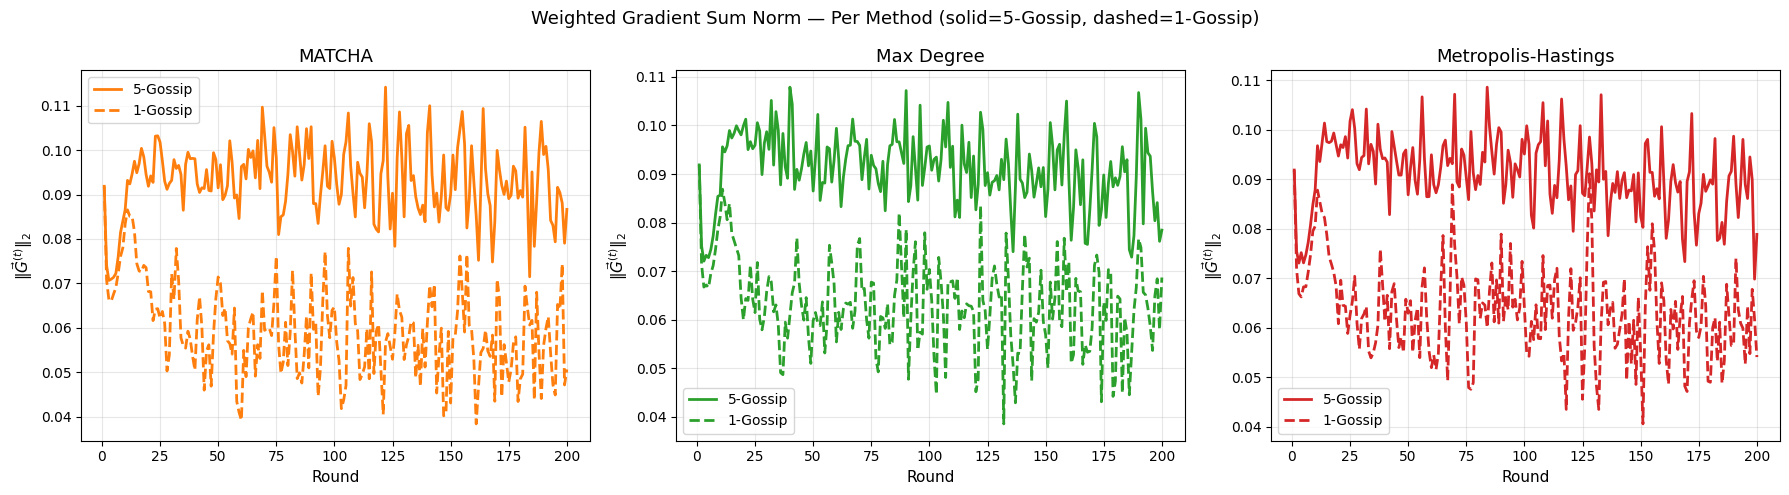

In [12]:
# ── Per-method 1×3: overlay both gossip configs ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (method, color) in zip(axes, zip(METHODS, colors)):
    for cfg_label, ls in linestyles.items():
        if method not in method_norms[cfg_label]:
            continue
        norms = method_norms[cfg_label][method]
        rs = sorted(norms.keys())
        ax.plot(rs, [norms[r] for r in rs], color=color,
                linewidth=2, linestyle=ls,
                label=cfg_label)
    ax.set_title(method, fontsize=13)
    ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel(r'$\|\vec{G}^{(t)}\|_2$', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Weighted Gradient Sum Norm — Per Method (solid=5-Gossip, dashed=1-Gossip)', fontsize=13)
plt.tight_layout()
plt.show()


### Cell 3 — Shadow FedAvg Global Test Accuracy
At each round, a **weighted-average model** is constructed from each client's pre-gossip state dict and evaluated on the full CIFAR-10 test set. This acts as a Shadow FedAvg oracle. The plot compares this global test accuracy across all three methods and both gossip configurations.


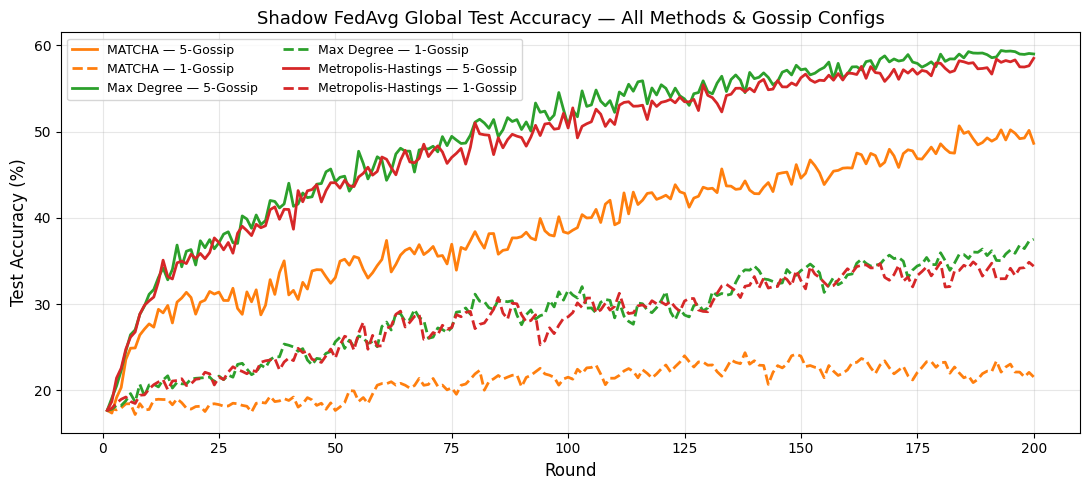

In [13]:
# ── Global Aggregated Metrics — all method × config combinations ──────────────
# global_metrics[cfg_label][method] = DataFrame
global_metrics = {cfg: {} for cfg in GOSSIP_CONFIGS}

for cfg_label, cfg_subdir in GOSSIP_CONFIGS.items():
    for method, base_dir in METHODS.items():
        try:
            exp_dir = get_exp_dir(base_dir, cfg_subdir)
            global_metrics[cfg_label][method] = pd.read_csv(exp_dir / 'global_aggregated_metrics.csv')
        except Exception as e:
            print(f'{cfg_label} / {method}: SKIPPED — {e}')

fig, ax = plt.subplots(figsize=(11, 5))

for method, color in zip(METHODS, colors):
    for cfg_label, ls in linestyles.items():
        if method not in global_metrics[cfg_label]:
            continue
        df = global_metrics[cfg_label][method]
        ax.plot(df['round'], df['test_accuracy'], color=color,
                linewidth=2, linestyle=ls,
                label=f'{method} — {cfg_label}')

ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Shadow FedAvg Global Test Accuracy — All Methods & Gossip Configs', fontsize=13)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Cell 4 — Pre-Gossip Client Metrics (All Methods)
Shows **test accuracy, train accuracy, and train loss** averaged across all clients per round, measured *before* gossip exchange. Each line represents one mixing method. This captures the quality of purely local training before any peer-to-peer model mixing occurs.

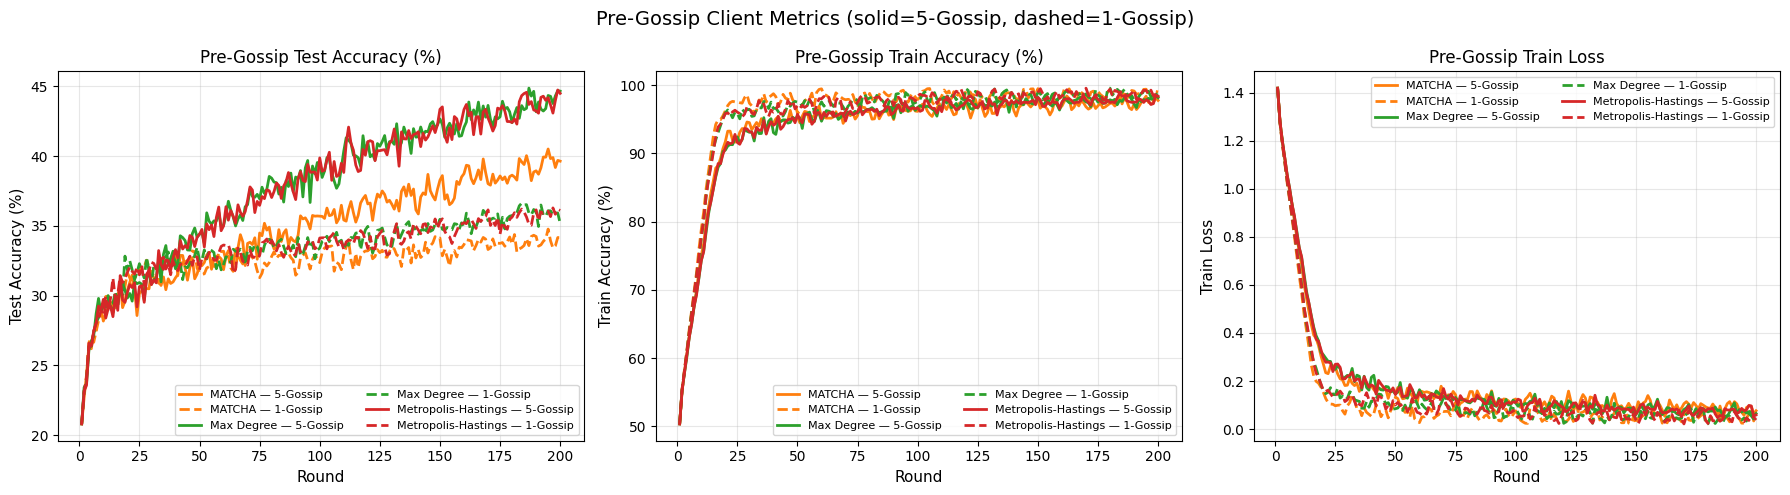

In [14]:
# ── Pre-Gossip Metrics — all method × config combinations ────────────────────
# pre_gossip[cfg_label][method] = grouped DataFrame
pre_gossip = {cfg: {} for cfg in GOSSIP_CONFIGS}

for cfg_label, cfg_subdir in GOSSIP_CONFIGS.items():
    for method, base_dir in METHODS.items():
        try:
            exp_dir = get_exp_dir(base_dir, cfg_subdir)
            df = pd.read_csv(exp_dir / 'pre_gossip_metrics.csv')
            pre_gossip[cfg_label][method] = df.groupby('round')[
                ['test_accuracy', 'train_accuracy', 'train_loss']].mean()
        except Exception as e:
            print(f'{cfg_label} / {method}: SKIPPED — {e}')

plot_cfg = [
    ('test_accuracy',  'Test Accuracy (%)'),
    ('train_accuracy', 'Train Accuracy (%)'),
    ('train_loss',     'Train Loss'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, ylabel) in zip(axes, plot_cfg):
    for method, color in zip(METHODS, colors):
        for cfg_label, ls in linestyles.items():
            if method not in pre_gossip[cfg_label]:
                continue
            df = pre_gossip[cfg_label][method]
            ax.plot(df.index, df[col], color=color,
                    linewidth=2, linestyle=ls,
                    label=f'{method} — {cfg_label}')
    ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Pre-Gossip {ylabel}', fontsize=12)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('Pre-Gossip Client Metrics (solid=5-Gossip, dashed=1-Gossip)', fontsize=14)
plt.tight_layout()
plt.show()


### Cell 5 — Post-Gossip Client Metrics (All Methods)
Same layout as above but sourced from `p2p_metrics.csv`, which records metrics *after* gossip aggregation. Comparing with Cell 4 reveals the effect of the mixing step: improved generalisation (higher test accuracy, lower loss) indicates effective knowledge sharing between peers.

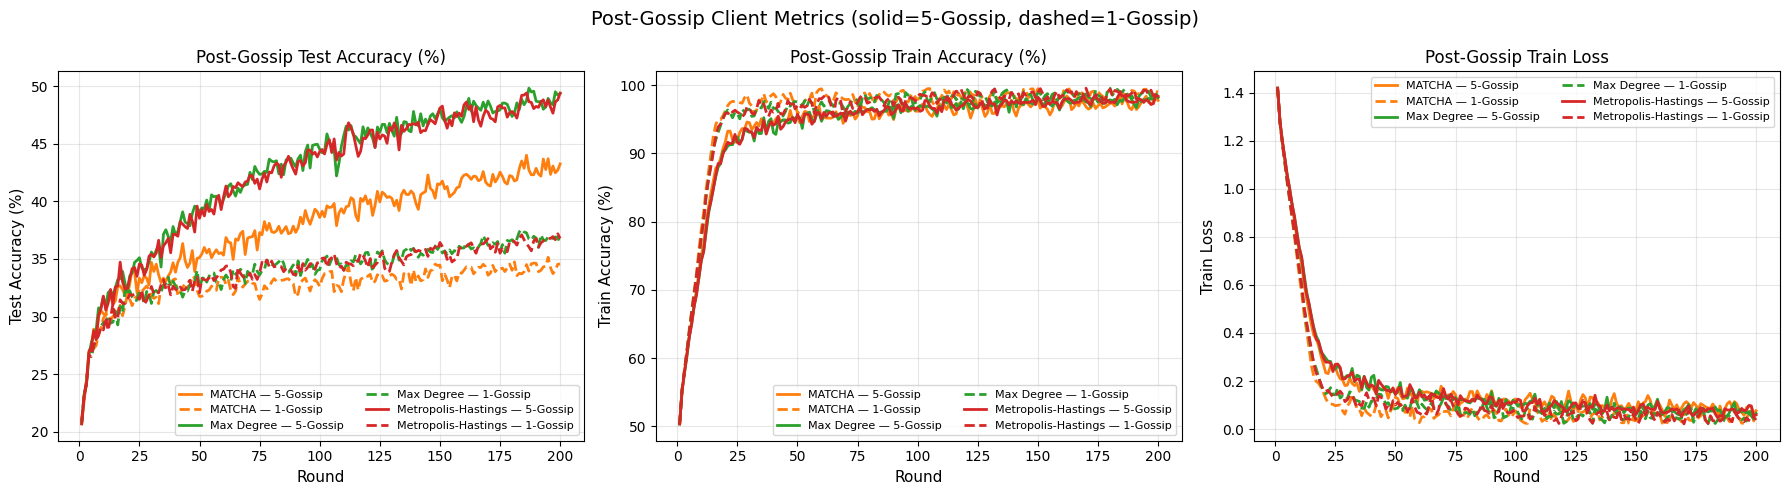

In [15]:
# ── Post-Gossip Metrics — all method × config combinations ───────────────────
# post_gossip[cfg_label][method] = grouped DataFrame
post_gossip = {cfg: {} for cfg in GOSSIP_CONFIGS}

for cfg_label, cfg_subdir in GOSSIP_CONFIGS.items():
    for method, base_dir in METHODS.items():
        try:
            exp_dir = get_exp_dir(base_dir, cfg_subdir)
            df = pd.read_csv(exp_dir / 'p2p_metrics.csv')
            post_gossip[cfg_label][method] = df.groupby('round')[
                ['test_accuracy', 'train_accuracy', 'train_loss']].mean()
        except Exception as e:
            print(f'{cfg_label} / {method}: SKIPPED — {e}')

plot_cfg = [
    ('test_accuracy',  'Test Accuracy (%)'),
    ('train_accuracy', 'Train Accuracy (%)'),
    ('train_loss',     'Train Loss'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, ylabel) in zip(axes, plot_cfg):
    for method, color in zip(METHODS, colors):
        for cfg_label, ls in linestyles.items():
            if method not in post_gossip[cfg_label]:
                continue
            df = post_gossip[cfg_label][method]
            ax.plot(df.index, df[col], color=color,
                    linewidth=2, linestyle=ls,
                    label=f'{method} — {cfg_label}')
    ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Post-Gossip {ylabel}', fontsize=12)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('Post-Gossip Client Metrics (solid=5-Gossip, dashed=1-Gossip)', fontsize=14)
plt.tight_layout()
plt.show()


### Cell 6 — Pre vs Post-Gossip Test Accuracy Per Method (1×3 Grid)
A direct **pre vs post-gossip comparison** of test accuracy for each mixing method in its own subplot. The dashed line is pre-gossip (local model only) and the solid line is post-gossip (after peer mixing). The gap between them quantifies how much each round of gossip improves test performance for that method.


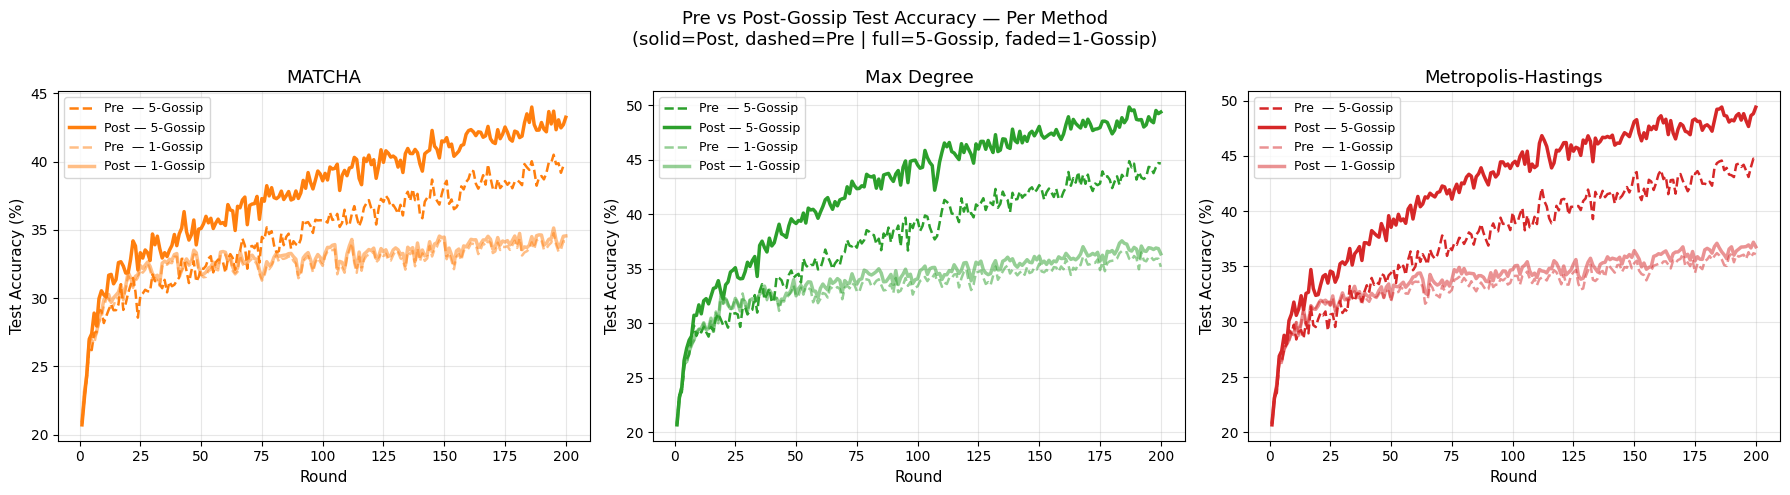

In [16]:
# ── Pre vs Post-Gossip Test Accuracy — Per Method, both gossip configs ────────
# 1×3 grid (one panel per method):
#   solid lines   = post-gossip
#   dashed lines  = pre-gossip
#   full alpha    = 5-Gossip
#   lower alpha   = 1-Gossip
cfg_alpha = {'5-Gossip': 1.0, '1-Gossip': 0.5}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (method, color) in zip(axes, zip(METHODS, colors)):
    for cfg_label, alpha in cfg_alpha.items():
        cfg_subdir = GOSSIP_CONFIGS[cfg_label]
        exp_dir    = get_exp_dir(METHODS[method], cfg_subdir)
        try:
            df_pre  = pd.read_csv(exp_dir / 'pre_gossip_metrics.csv')
            df_post = pd.read_csv(exp_dir / 'p2p_metrics.csv')
            pre_ser  = df_pre.groupby('round')['test_accuracy'].mean()
            post_ser = df_post.groupby('round')['test_accuracy'].mean()
            ax.plot(pre_ser.index,  pre_ser,  color=color, linewidth=1.8,
                    linestyle='--', alpha=alpha,
                    label=f'Pre  — {cfg_label}')
            ax.plot(post_ser.index, post_ser, color=color, linewidth=2.5,
                    linestyle='-', alpha=alpha,
                    label=f'Post — {cfg_label}')
        except Exception as e:
            print(f'{cfg_label} / {method}: SKIPPED — {e}')
    ax.set_title(method, fontsize=13)
    ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel('Test Accuracy (%)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Pre vs Post-Gossip Test Accuracy — Per Method\n'
             '(solid=Post, dashed=Pre | full=5-Gossip, faded=1-Gossip)', fontsize=13)
plt.tight_layout()
plt.show()


### Cell 7 — Shadow FedAvg vs Post-Gossip Test Accuracy Per Method (1×3 Grid)
Compares, per method, the **Shadow FedAvg global model** (weighted average of all client models before gossip, evaluated on the full test set — from `global_aggregated_metrics.csv`) against the **post-gossip mean client test accuracy** (from `p2p_metrics.csv`).  
The gap between the two lines shows how close gossip-based mixing gets to the centralised Shadow FedAvg upper bound.


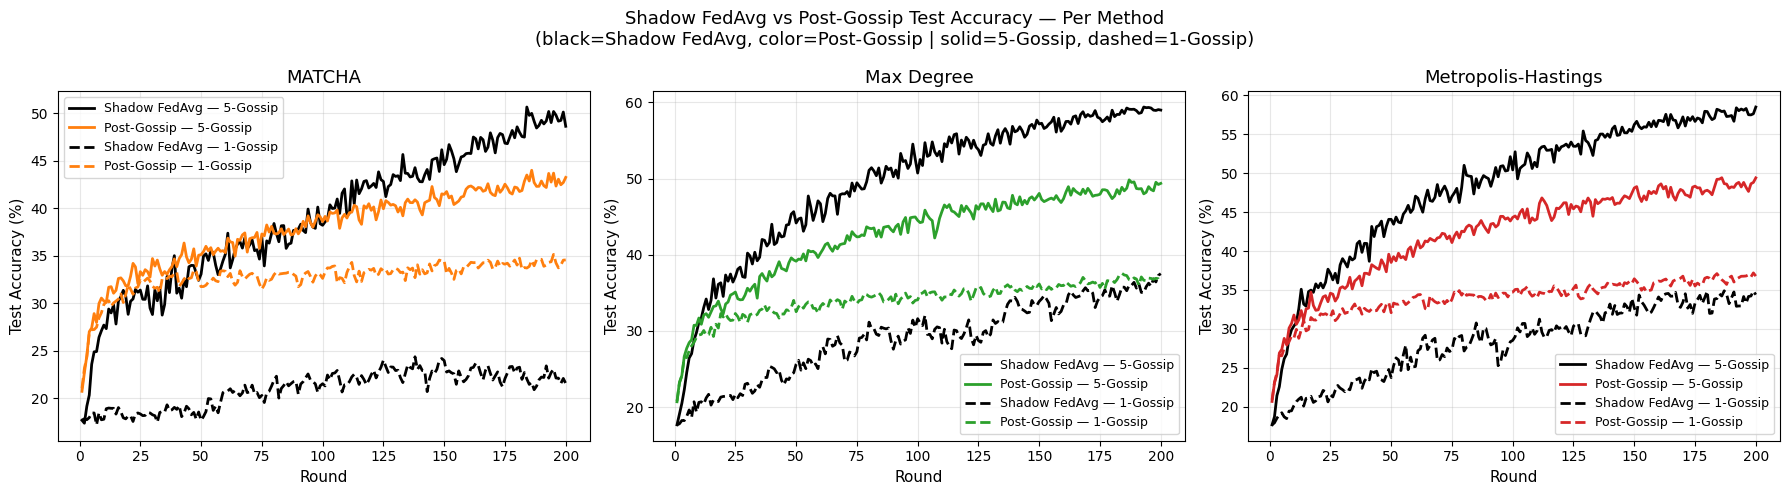

In [17]:
# ── Shadow FedAvg vs Post-Gossip — Per Method, both gossip configs ───────────
# solid = 5-Gossip, dashed = 1-Gossip
# black = Shadow FedAvg, color = Post-Gossip

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (method, color) in zip(axes, zip(METHODS, colors)):
    for cfg_label, ls in linestyles.items():
        exp_dir = get_exp_dir(METHODS[method], GOSSIP_CONFIGS[cfg_label])
        try:
            glob_ser = pd.read_csv(exp_dir / 'global_aggregated_metrics.csv').set_index('round')['test_accuracy']
            post_ser = pd.read_csv(exp_dir / 'p2p_metrics.csv').groupby('round')['test_accuracy'].mean()
            ax.plot(glob_ser.index, glob_ser.values, color='black',  linewidth=2,
                    linestyle=ls, label=f'Shadow FedAvg — {cfg_label}')
            ax.plot(post_ser.index, post_ser.values, color=color,
                    linewidth=2, linestyle=ls,
                    label=f'Post-Gossip — {cfg_label}')
        except Exception as e:
            print(f'{cfg_label} / {method}: SKIPPED — {e}')
    ax.set_title(method, fontsize=13)
    ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel('Test Accuracy (%)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Shadow FedAvg vs Post-Gossip Test Accuracy — Per Method\n'
             '(black=Shadow FedAvg, color=Post-Gossip | solid=5-Gossip, dashed=1-Gossip)', fontsize=13)
plt.tight_layout()
plt.show()


### Cell 8 — Weight Magnitude (MG) per Round

Tracks the **update magnitude gradient** at each round, defined per layer $l$ as:

$$\text{MG}_t^{(l)} = \|w_t^{(l)} - w_{t-1}^{(l)}\|_2$$

where $w_t^{(l)}$ is the **weighted-average global model** parameter vector for layer $l$ at round $t$ (computed from `pre_gossip_weights/round_t.pt`).

- The **total MG** is plotted per round for each mixing method on a single axes.  
- A **1×3 per-method grid** is also shown for individual inspection.  
- Larger values indicate stronger parameter updates; a decaying MG indicates the model is converging to a stable solution.


5-Gossip / MATCHA
5-Gossip / Max Degree
5-Gossip / Metropolis-Hastings
1-Gossip / MATCHA
1-Gossip / Max Degree
1-Gossip / Metropolis-Hastings


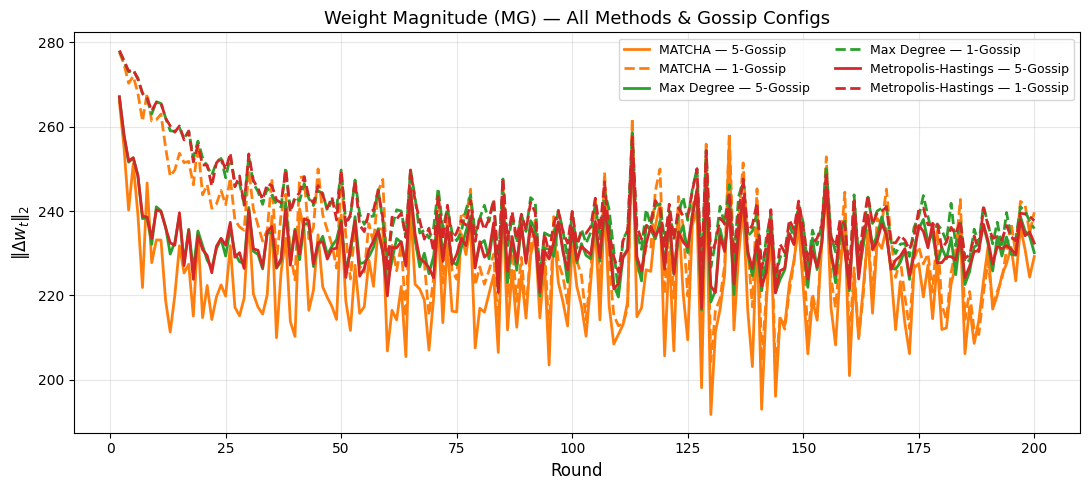

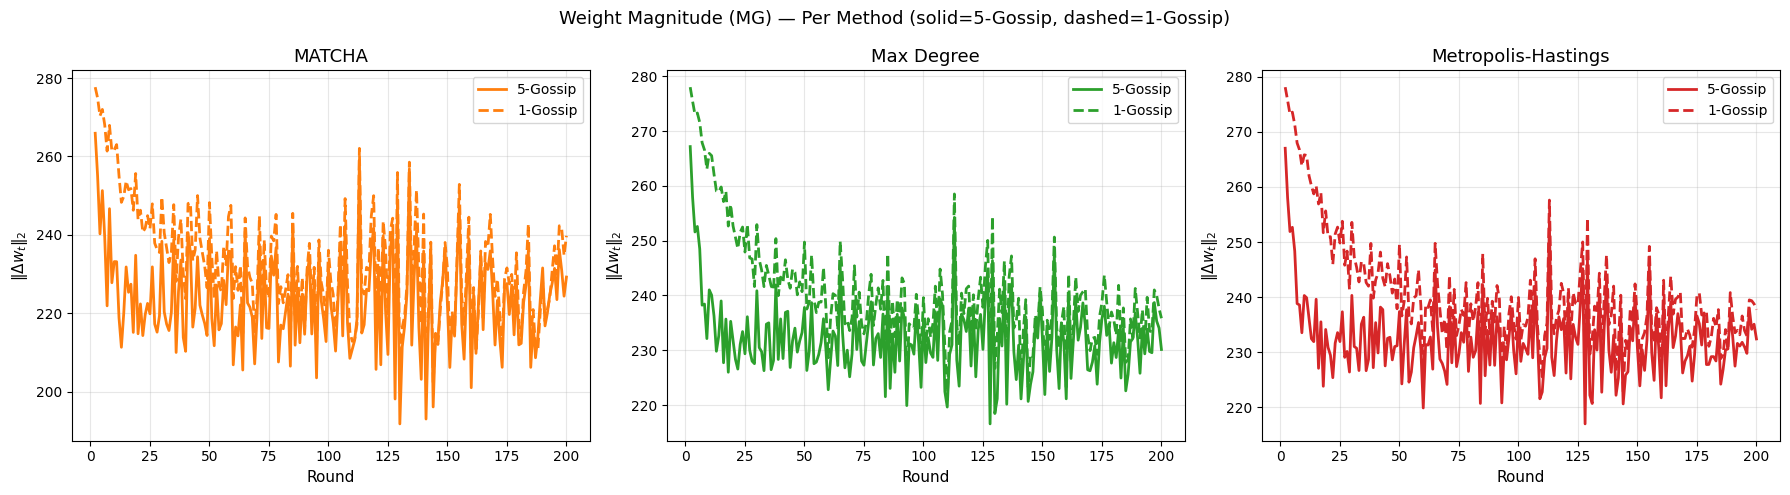

In [18]:
import torch

def compute_weight_magnitudes(exp_dir: Path):
    """
    Per round:
      1. Load pre_gossip_weights/round_t.pt  →  {client_id: state_dict}
      2. Flatten each client's state dict into a single 1-D vector
      3. Weighted average (n_i from pre_gossip_metrics.csv)  →  global flat vector w_t
      4. Diff between consecutive rounds  →  Δw_t = w_t − w_{t−1}
      5. L2 norm  →  MG_t = ‖Δw_t‖₂
    Returns dict: round -> MG (float)
    """
    weights_dir = exp_dir / 'pre_gossip_weights'
    pt_files = sorted(weights_dir.glob('round_*.pt'),
                      key=lambda f: int(f.stem.split('_')[1]))
    if len(pt_files) < 2:
        raise FileNotFoundError(f'Not enough weight files in {weights_dir}')

    df_pre      = pd.read_csv(exp_dir / 'pre_gossip_metrics.csv')
    first_round = int(pt_files[0].stem.split('_')[1])
    r0          = df_pre[df_pre['round'] == first_round].set_index('client_id')
    client_ids  = sorted(r0.index.tolist())
    num_samples = {cid: int(r0.loc[cid, 'num_samples']) for cid in client_ids}
    total       = sum(num_samples.values())
    w_i         = {cid: num_samples[cid] / total for cid in client_ids}

    global_flat = {}
    for pt in pt_files:
        r  = int(pt.stem.split('_')[1])
        sd = torch.load(pt, map_location='cpu')
        client_flat = {
            cid: torch.cat([p.float().flatten() for p in sd[cid].values()])
            for cid in client_ids if cid in sd
        }
        global_flat[r] = sum(w_i[cid] * client_flat[cid] for cid in client_flat)

    rounds = sorted(global_flat.keys())
    mg = {}
    for t, t_prev in zip(rounds[1:], rounds[:-1]):
        mg[t] = float(torch.norm(global_flat[t] - global_flat[t_prev]))
    return mg

# ── Compute weight magnitudes for all method × config combinations ────────────
wm_total = {cfg: {} for cfg in GOSSIP_CONFIGS}

for cfg_label, cfg_subdir in GOSSIP_CONFIGS.items():
    for method, base_dir in METHODS.items():
        try:
            exp_dir = get_exp_dir(base_dir, cfg_subdir)
            print(f'{cfg_label} / {method}')
            wm_total[cfg_label][method] = compute_weight_magnitudes(exp_dir)
        except Exception as e:
            print(f'{cfg_label} / {method}: SKIPPED — {e}')

# ── Plot: all methods × configs on one axes ───────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

for method, color in zip(METHODS, colors):
    for cfg_label, ls in linestyles.items():
        if method not in wm_total[cfg_label]:
            continue
        mg = wm_total[cfg_label][method]
        rs = sorted(mg.keys())
        ax.plot(rs, [mg[r] for r in rs], color=color,
                linewidth=2, linestyle=ls,
                label=f'{method} — {cfg_label}')

ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel(r'$\|\Delta w_t\|_2$', fontsize=12)
ax.set_title('Weight Magnitude (MG) — All Methods & Gossip Configs', fontsize=13)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot: 1×3 per method, overlay both configs ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (method, color) in zip(axes, zip(METHODS, colors)):
    for cfg_label, ls in linestyles.items():
        if method not in wm_total[cfg_label]:
            continue
        mg = wm_total[cfg_label][method]
        rs = sorted(mg.keys())
        ax.plot(rs, [mg[r] for r in rs], color=color,
                linewidth=2, linestyle=ls,
                label=cfg_label)
    ax.set_title(method, fontsize=13)
    ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel(r'$\|\Delta w_t\|_2$', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Weight Magnitude (MG) — Per Method (solid=5-Gossip, dashed=1-Gossip)', fontsize=13)
plt.tight_layout()
plt.show()


In [19]:
# ── Export all figures for LaTeX report ───────────────────────────────────────
FIG_DIR.mkdir(parents=True, exist_ok=True)

# helper to add method×config lines to an axes
def _add_lines_norm(ax, data, ylabel):
    for method, color in zip(METHODS, colors):
        for cfg_label, ls in linestyles.items():
            if method not in data[cfg_label]:
                continue
            norms = data[cfg_label][method]
            rs = sorted(norms.keys())
            ax.plot(rs, [norms[r] for r in rs], color=color,
                    linewidth=2, linestyle=ls,
                    label=f'{method} — {cfg_label}')
    ax.set_xlabel('Round', fontsize=12); ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)

# ── 1. Grad norm — all ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
_add_lines_norm(ax, method_norms, r'$\|\vec{G}^{(t)}\|_2$')
ax.set_title('Weighted Gradient Sum Norm per Round', fontsize=13); plt.tight_layout()
fig.savefig(FIG_DIR / 'grad_norm_all.png', dpi=DPI); plt.close(fig)

# ── 2. Grad norm — 1×3 per method ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (method, color) in zip(axes, zip(METHODS, colors)):
    for cfg_label, ls in linestyles.items():
        if method not in method_norms[cfg_label]: continue
        norms = method_norms[cfg_label][method]; rs = sorted(norms.keys())
        ax.plot(rs, [norms[r] for r in rs], color=color,
                linewidth=2, linestyle=ls, label=cfg_label)
    ax.set_title(method, fontsize=13); ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel(r'$\|\vec{G}^{(t)}\|_2$', fontsize=11); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.suptitle('Weighted Gradient Sum Norm — Per Method', fontsize=14); plt.tight_layout()
fig.savefig(FIG_DIR / 'grad_norm_grid.png', dpi=DPI); plt.close(fig)

# ── 3. Shadow FedAvg ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for method, color in zip(METHODS, colors):
    for cfg_label, ls in linestyles.items():
        if method not in global_metrics[cfg_label]: continue
        df = global_metrics[cfg_label][method]
        ax.plot(df['round'], df['test_accuracy'], color=color,
                linewidth=2, linestyle=ls, label=f'{method} — {cfg_label}')
ax.set_xlabel('Round', fontsize=12); ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Shadow FedAvg Global Test Accuracy', fontsize=13)
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(FIG_DIR / 'fedavg_accuracy.png', dpi=DPI); plt.close(fig)

# ── helper for 1×3 metric plots ───────────────────────────────────────────────
def _save_metric_grid(data, suptitle, fname):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (col, ylabel) in zip(axes, [('test_accuracy','Test Accuracy (%)'),
                                         ('train_accuracy','Train Accuracy (%)'),
                                         ('train_loss','Train Loss')]):
        for method, color in zip(METHODS, colors):
            for cfg_label, ls in linestyles.items():
                if method not in data[cfg_label]: continue
                df = data[cfg_label][method]
                ax.plot(df.index, df[col], color=color,
                        linewidth=2, linestyle=ls,
                        label=f'{method} — {cfg_label}')
        ax.set_xlabel('Round', fontsize=11); ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(ylabel, fontsize=12); ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
    plt.suptitle(suptitle, fontsize=14); plt.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=DPI); plt.close(fig)

# ── 4 & 5. Pre / Post gossip metrics ─────────────────────────────────────────
_save_metric_grid(pre_gossip,  'Pre-Gossip Client Metrics',  'pre_gossip_metrics.png')
_save_metric_grid(post_gossip, 'Post-Gossip Client Metrics', 'post_gossip_metrics.png')

# ── 6. Pre vs Post per method ─────────────────────────────────────────────────
cfg_alpha = {'5-Gossip': 1.0, '1-Gossip': 0.5}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (method, color) in zip(axes, zip(METHODS, colors)):
    for cfg_label, alpha in cfg_alpha.items():
        exp_dir = get_exp_dir(METHODS[method], GOSSIP_CONFIGS[cfg_label])
        try:
            pre_s  = pd.read_csv(exp_dir/'pre_gossip_metrics.csv').groupby('round')['test_accuracy'].mean()
            post_s = pd.read_csv(exp_dir/'p2p_metrics.csv').groupby('round')['test_accuracy'].mean()
            ax.plot(pre_s.index,  pre_s,  color=color, linestyle='--', linewidth=1.8,
                    alpha=alpha, label=f'Pre — {cfg_label}')
            ax.plot(post_s.index, post_s, color=color, linestyle='-',  linewidth=2.5,
                    alpha=alpha, label=f'Post — {cfg_label}')
        except: pass
    ax.set_title(method, fontsize=13); ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel('Test Accuracy (%)', fontsize=11); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle('Pre vs Post-Gossip Test Accuracy — Per Method', fontsize=14); plt.tight_layout()
fig.savefig(FIG_DIR / 'pre_vs_post.png', dpi=DPI); plt.close(fig)

# ── 7. Shadow FedAvg vs Post-Gossip per method ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (method, color) in zip(axes, zip(METHODS, colors)):
    for cfg_label, ls in linestyles.items():
        exp_dir = get_exp_dir(METHODS[method], GOSSIP_CONFIGS[cfg_label])
        try:
            g = pd.read_csv(exp_dir/'global_aggregated_metrics.csv').set_index('round')['test_accuracy']
            p = pd.read_csv(exp_dir/'p2p_metrics.csv').groupby('round')['test_accuracy'].mean()
            ax.plot(g.index, g.values, color='black', linewidth=2, linestyle=ls, label=f'Shadow FedAvg — {cfg_label}')
            ax.plot(p.index, p.values, color=color, linewidth=2, linestyle=ls, label=f'Post — {cfg_label}')
        except: pass
    ax.set_title(method, fontsize=13); ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel('Test Accuracy (%)', fontsize=11); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle('Shadow FedAvg vs Post-Gossip — Per Method', fontsize=14); plt.tight_layout()
fig.savefig(FIG_DIR / 'fedavg_vs_postgossip.png', dpi=DPI); plt.close(fig)

# ── 8. Weight magnitude — all ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for method, color in zip(METHODS, colors):
    for cfg_label, ls in linestyles.items():
        if method not in wm_total[cfg_label]: continue
        mg = wm_total[cfg_label][method]; rs = sorted(mg.keys())
        ax.plot(rs, [mg[r] for r in rs], color=color,
                linewidth=2, linestyle=ls, label=f'{method} — {cfg_label}')
ax.set_xlabel('Round', fontsize=12); ax.set_ylabel(r'$\|\Delta w_t\|_2$', fontsize=12)
ax.set_title('Weight Magnitude (MG) per Round', fontsize=13)
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(FIG_DIR / 'weight_mag_all.png', dpi=DPI); plt.close(fig)

# ── 9. Weight magnitude — 1×3 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (method, color) in zip(axes, zip(METHODS, colors)):
    for cfg_label, ls in linestyles.items():
        if method not in wm_total[cfg_label]: continue
        mg = wm_total[cfg_label][method]; rs = sorted(mg.keys())
        ax.plot(rs, [mg[r] for r in rs], color=color,
                linewidth=2, linestyle=ls, label=cfg_label)
    ax.set_title(method, fontsize=13); ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel(r'$\|\Delta w_t\|_2$', fontsize=11); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.suptitle('Weight Magnitude (MG) — Per Method', fontsize=14); plt.tight_layout()
fig.savefig(FIG_DIR / 'weight_mag_grid.png', dpi=DPI); plt.close(fig)

print('Figures saved to', FIG_DIR.resolve())
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name}')


Figures saved to /home/skacem/FLF/report/figures
  fedavg_accuracy.png
  fedavg_vs_postgossip.png
  grad_norm_all.png
  grad_norm_grid.png
  post_gossip_metrics.png
  pre_gossip_metrics.png
  pre_vs_post.png
  weight_mag_all.png
  weight_mag_grid.png
